# 01 — EDA: Audio Features

Análisis exploratorio de las características de audio extraídas del dataset descargado, que fue generado mediante la extracción de datos de la API en 2024.


## 1. Imports y carga de datos 

Se establece la configuración de las librerías que se van a utilizar.

In [34]:
# Librerías de manipulación de datos.
import pandas as pd
import numpy as np


# Librerías de visualización.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import plotly.express as px

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

# Configuración de warnings.
import warnings
warnings.filterwarnings('ignore')

A continuación, se carga el dataset con el que se trabajará.

In [18]:
ruta = '../data/raw/dataset.csv'
df_raw = pd.read_csv(ruta)

print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]}")
print(f"\nColumnas disponibles:\n{list(df_raw.columns)}")

Filas: 114,000
Columnas: 21

Columnas disponibles:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


## 2. Limpieza y preprocesamiento

Buscaremos información sobre la estructura que conforma el conjunto de datos y puede que se realice algún cambio minoritario.

In [19]:
df_raw.head(10)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,6,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,2,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,11,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,0,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,1,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


Para comenzar, se eliminará la columna Unamed : 0 y track_id, ya que no aportan información al análisis.

In [20]:
# Trabajamos siempre desde una copia.
df = df_raw.copy()

# Eliminamos la columna 'Unnamed: 0' y 'track_id' que es un índice innecesario.
df.drop(columns=['Unnamed: 0', 'track_id'], inplace=True)
print(f'Columnas eliminadas correctamente!')

Columnas eliminadas correctamente!


Mostramos los tipos de datos que conforman el dataset, los valores nulos y los duplicados.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  object 
 1   album_name        113999 non-null  object 
 2   track_name        113999 non-null  object 
 3   popularity        114000 non-null  int64  
 4   duration_ms       114000 non-null  int64  
 5   explicit          114000 non-null  bool   
 6   danceability      114000 non-null  float64
 7   energy            114000 non-null  float64
 8   key               114000 non-null  int64  
 9   loudness          114000 non-null  float64
 10  mode              114000 non-null  int64  
 11  speechiness       114000 non-null  float64
 12  acousticness      114000 non-null  float64
 13  instrumentalness  114000 non-null  float64
 14  liveness          114000 non-null  float64
 15  valence           114000 non-null  float64
 16  tempo             11

In [22]:
print(f'\nValores nulos por columna:')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'No hay valores nulos en el dataset.')

print(f'\nDuplicados:')
dups = df.duplicated().sum()
print(f'Número de canciones duplicadas: {dups}')



Valores nulos por columna:
artists       1
album_name    1
track_name    1
dtype: int64

Duplicados:
Número de canciones duplicadas: 577


Estadísticas descriptivas de las variables numéricas

In [23]:
# Escogemos valores numéricos
audio_feat = ['danceability', 'energy', 'loudness', 'speechiness','acousticness', 'instrumentalness', 'liveness','valence', 'tempo', 'popularity']

df[audio_feat].describe().round(3)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,0.567,0.641,-8.259,0.085,0.315,0.156,0.214,0.474,122.148,33.239
std,0.174,0.252,5.029,0.106,0.333,0.310,0.190,0.259,29.978,22.305
min,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.456,0.472,-10.013,0.036,0.017,0.000,0.098,0.260,99.219,17.000
50%,0.580,0.685,-7.004,0.049,0.169,0.000,0.132,0.464,122.017,35.000
75%,0.695,0.854,-5.003,0.084,0.598,0.049,0.273,0.683,140.071,50.000
max,0.985,1.000,4.532,0.965,0.996,1.000,1.000,0.995,243.372,100.000


Tras comprobar que hay 577 valores duplicados y 1 valor nulo, procedemos a eliminarlos.

In [24]:
# Eliminar filas con valores nulos.
df = df.dropna(subset=['artists', 'album_name', 'track_name'])

# Eliminar duplicados.
df = df.drop_duplicates()

# Reset del índice.
df = df.reset_index(drop=True)

print(f"Dataset limpio: {df.shape[0]:,} filas, {df.shape[1]} columnas")

Dataset limpio: 113,422 filas, 19 columnas


Modificamos la duración de las canciones de ms a minutos para que sea más legible, y categorizamos la popularidad en varios rangos.

In [25]:
# Cambiamos la duración a minutos.
df['duration_min'] = (df['duration_ms'] / 60000).round(2)

# Categorizamos la popularidad en rangos.
df['popularity_category'] = pd.cut(df['popularity'], bins=[0, 25, 50, 75, 100], labels=['Baja', 'Media', 'Alta', 'Viral'])

print(f'Distribución por categoría de popularidad:')
print(df['popularity_category'].value_counts()) 

Distribución por categoría de popularidad:
popularity_category
Media    41758
Baja     28191
Alta     25335
Viral     2412
Name: count, dtype: int64


Terminamos preprocesamiento. Guardamos dataset y pasamos a EDA.

In [26]:
df.to_csv('../data/processed/dataset_clean.csv', index=False)
print(f'Dataset guardado en ../data/processed/dataset_clean.csv')
print(f'Estructura final: {df.shape[0]} canciones, {df.shape[1]} features')

Dataset guardado en ../data/processed/dataset_clean.csv
Estructura final: 113422 canciones, 21 features


### Análisis Exploratorio de Datos (EDA)

#### Distribución de features de audio

Comenzamos mostrando las distintas distribuciones de las features de audio.

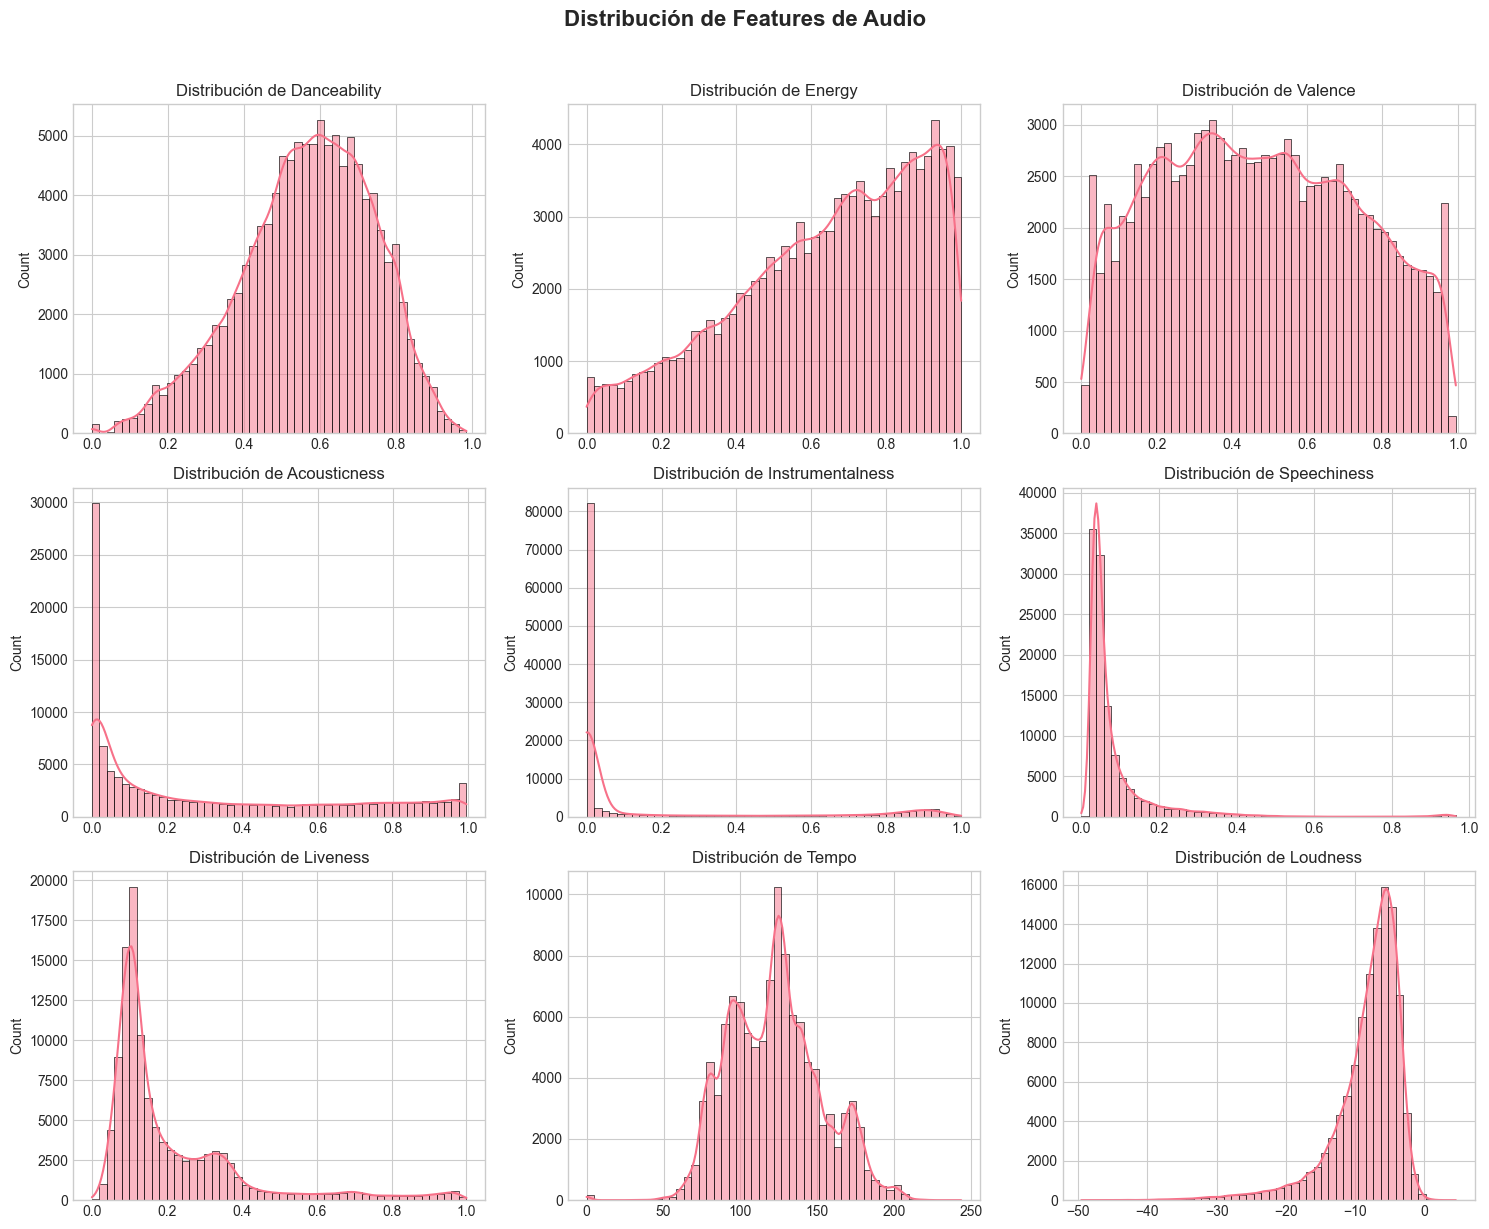

In [27]:
# Configuración del gráfico.
fig, axes = plt.subplots(3,3, figsize=(15,12))
fig.suptitle('Distribución de Features de Audio', fontsize=16, fontweight='bold', y=1.02)

# Elección de features.
features = ['danceability', 'energy', 'valence','acousticness', 'instrumentalness', 'speechiness','liveness', 'tempo', 'loudness']

# Iteración sobre las features.
for ax, feature in zip(axes.flatten(), features):
    sns.histplot(df[feature], bins=50, ax=ax, kde=True)
    ax.set_title(f'Distribución de {feature.capitalize()}')
    ax.set_xlabel('')
    
# Mostrar gráfico.
plt.tight_layout()
plt.savefig('../reports/figures/distribucion_audio_features.png', dpi=150, bbox_inches='tight')
plt.show()



Podemos ver toda clase de distribuciones, sesgos a izquierda y derecha, normales (Gaussianas).

#### Análisis de popularidad

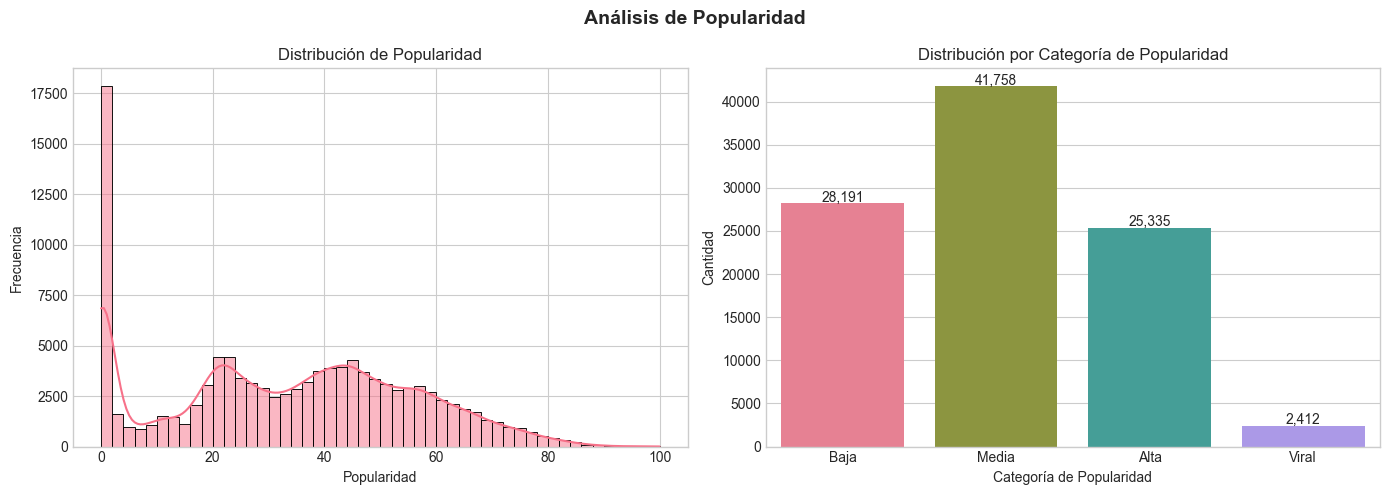

In [28]:
# Configuración del gráfico.
fig, axes = plt.subplots(1,2, figsize=(14,5))
fig.suptitle('Análisis de Popularidad', fontsize=14, fontweight='bold')

# Histograma.
sns.histplot(df['popularity'], ax=axes[0], bins=50, kde=True)
axes[0].set_title('Distribución de Popularidad')
axes[0].set_xlabel('Popularidad')
axes[0].set_ylabel('Frecuencia')

# Categorías
order = ['Baja', 'Media', 'Alta', 'Viral']
counts = df['popularity_category'].value_counts().reindex(order)
sns.barplot(x=counts.index, y=counts.values, ax=axes[1], palette='husl')
axes[1].set_title('Distribución por Categoría de Popularidad')
axes[1].set_xlabel('Categoría de Popularidad')
axes[1].set_ylabel('Cantidad')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('../reports/figures/distribucion_popularidad.png', dpi=150, bbox_inches='tight')
plt.show()

La distribución sesgada a la izquierda tiene mucho sentido, ya que la mayoría de canciones de Spotify no son conocidas.

#### Top Géneros

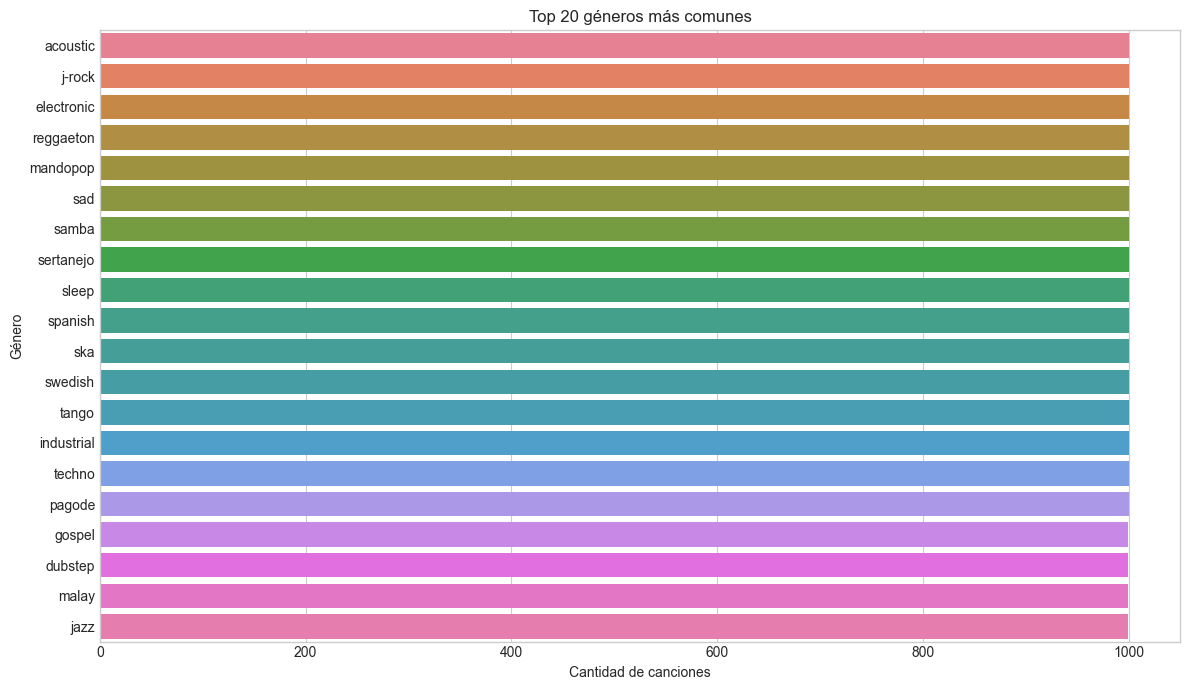


Total de géneros únicos: 114


In [29]:
# Seleccionar los 20 géneros más comunes
top_generos = df['track_genre'].value_counts().head(20)

# Configuración de gráfico.
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=top_generos.values, y=top_generos.index, ax=ax, palette='husl')
ax.set_xlabel('Cantidad de canciones')
ax.set_ylabel('Género')
ax.set_title('Top 20 géneros más comunes')

# Mostrar el gráfico.
plt.tight_layout()
plt.savefig('../reports/figures/top_generos.png', dpi=150, bbox_inches='tight')
plt.show()

# Total de géneros únicos.
print(f"\nTotal de géneros únicos: {df['track_genre'].nunique()}")


El dataset se encuentra balanceado en cuanto a géneros se trata, ya que cada género tiene aproximadamente la misma cantidad de canciones. Óptimo para el entrenamiento del modelo de recomendación.

#### Correlación de las features de audio

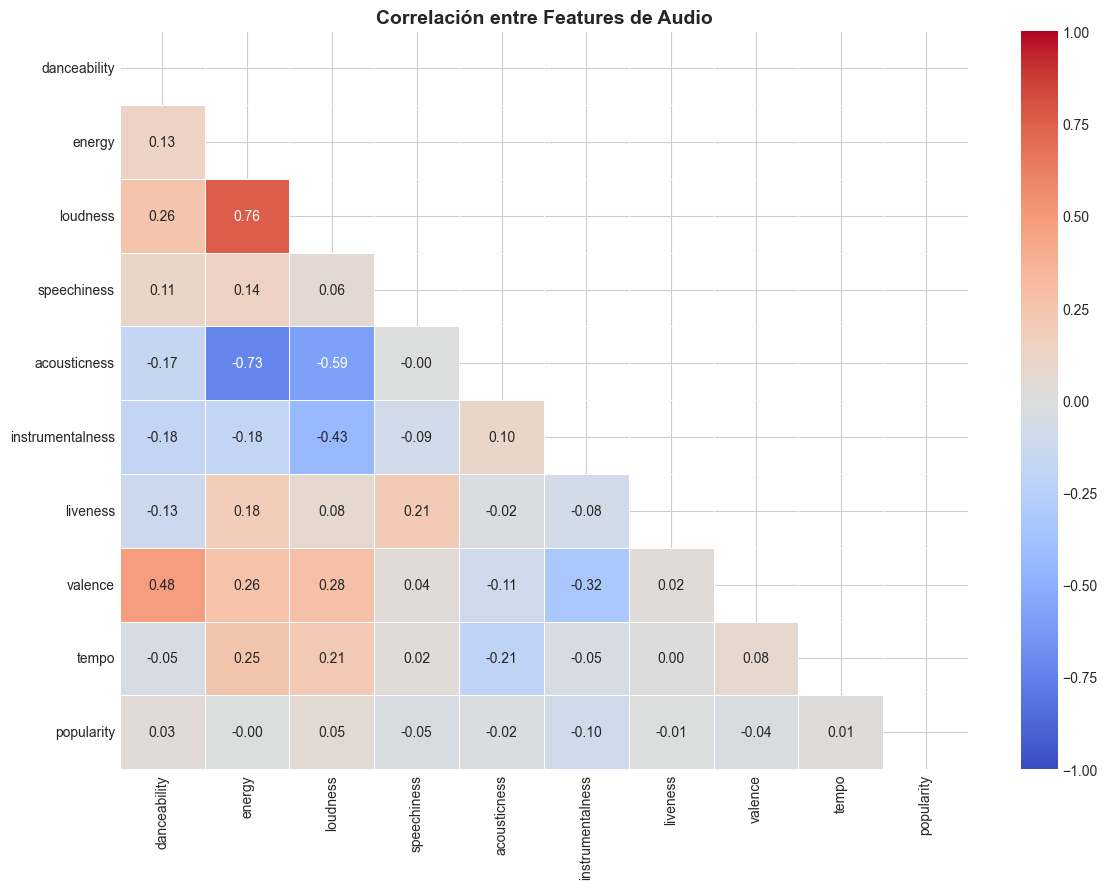

In [31]:
# Selección de features de audio.
audio_features = ['danceability', 'energy', 'loudness', 'speechiness','acousticness', 'instrumentalness', 'liveness','valence', 'tempo', 'popularity']

# Carga de matriz.
corr_matrix = df[audio_features].corr()

# Configuración de gráfico.
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,mask=mask,annot=True,fmt='.2f',cmap='coolwarm',center=0,vmin=-1, vmax=1,ax=ax,linewidths=0.5)
ax.set_title('Correlación entre Features de Audio', fontsize=14, fontweight='bold')

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('../reports/figures/correlacion_features.png', dpi=150, bbox_inches='tight')
plt.show()

La correlación más alta es 'loudness' y 'energy', con 0.76. La mayoría de las correlaciones son débiles o moderadas. 'Valence' tiene una correlación de 0.48 con 'danceability'.

Por otro lado, 'acousticness' tiene una correlación de -0,73 y -0,59 con energy y loudness. Tiene mucho sentido, ya que las canciones acústicas suelen ser más suaves y tranquilas.

#### Correlaciones con popularidad

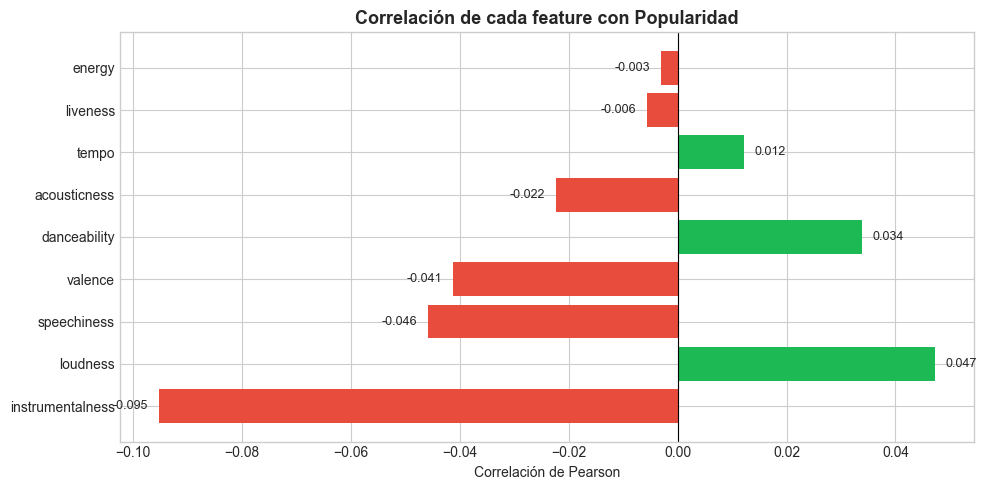

In [32]:
# Configuración de matriz.
corr_popularidad = corr_matrix['popularity'].drop('popularity').sort_values(key=abs, ascending=False)

# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#1DB954' if v > 0 else '#E74C3C' for v in corr_popularidad.values]
bars = ax.barh(corr_popularidad.index, corr_popularidad.values, color=colores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de cada feature con Popularidad', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')

for bar, val in zip(bars, corr_popularidad.values):
    ax.text(
        val + (0.002 if val >= 0 else -0.002),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )
    
# Mostrar gráfico.
plt.tight_layout()
plt.savefig('../reports/figures/correlacion_popularidad.png', dpi=150, bbox_inches='tight')
plt.show()

No hay un valor positivo de correlación con popularidad mayor a 0,047. Por la parte negativa, es aproximadamente 0,10. Lo que quiere decir que no hay una correlación fuerte entre las características audio y la popularidad.

#### Análisis de géneros

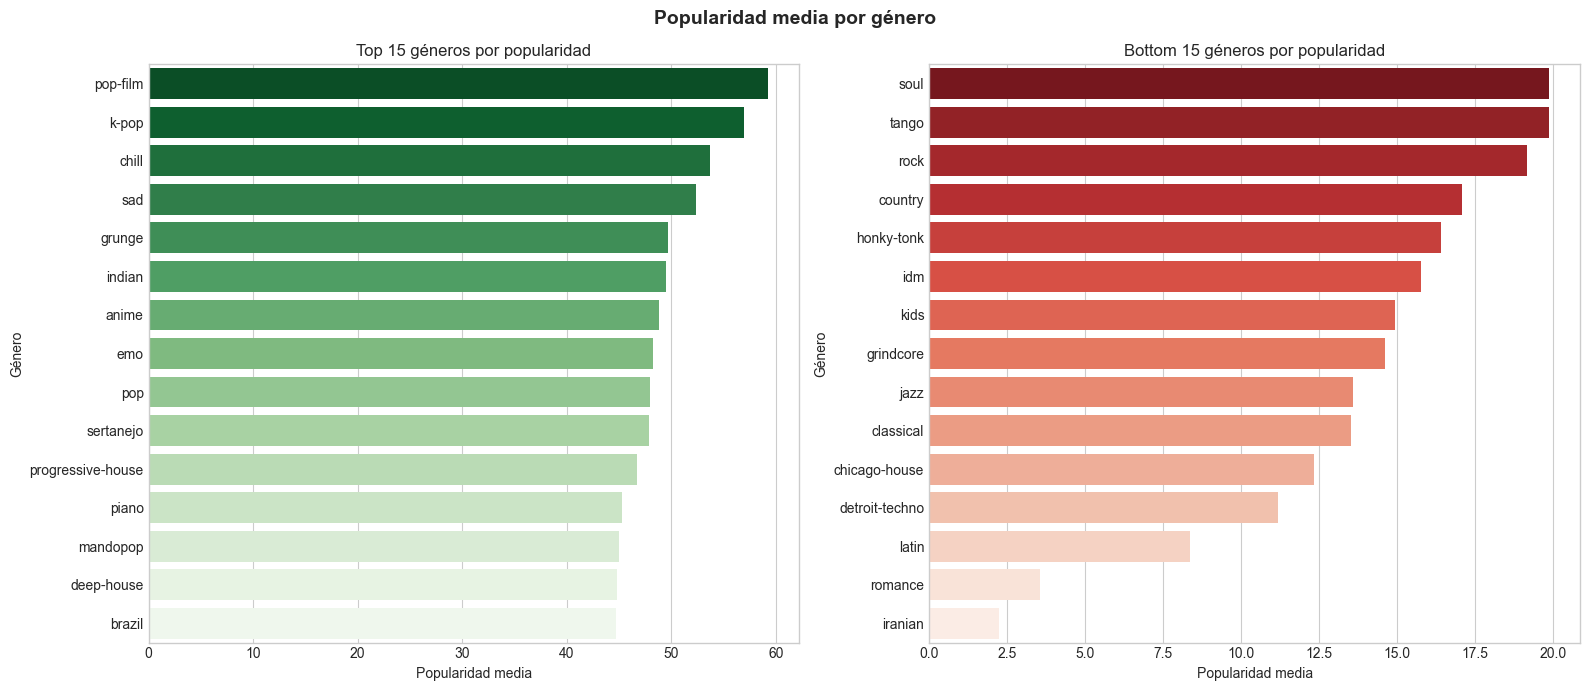

In [33]:
# Filtro por género.
pop_genre = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

# Configuración del gráfico.
fig, axes = plt.subplots(1,2, figsize=(16,7))
fig.suptitle('Popularidad media por género', fontsize=14, fontweight='bold')

# Gráfico de barras con el Top 15.
sns.barplot(x=pop_genre.head(15).values, y=pop_genre.head(15).index, palette='Greens_r', ax=axes[0])
axes[0].set_title('Top 15 géneros por popularidad')
axes[0].set_xlabel('Popularidad media')
axes[0].set_ylabel('Género')

# Gráfico de barras con el Bottom 15.
sns.barplot(x=pop_genre.tail(15).values, y=pop_genre.tail(15).index, palette='Reds_r', ax=axes[1])
axes[1].set_title('Bottom 15 géneros por popularidad')
axes[1].set_xlabel('Popularidad media')
axes[1].set_ylabel('Género')

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('../reports/figures/popularidad_por_genero.png', dpi=150, bbox_inches='tight')
plt.show()

La popularidad media más alta es de aproximadamente 60, y la más baja es de menos de 2,5. 

#### Perfil de Features de Audio

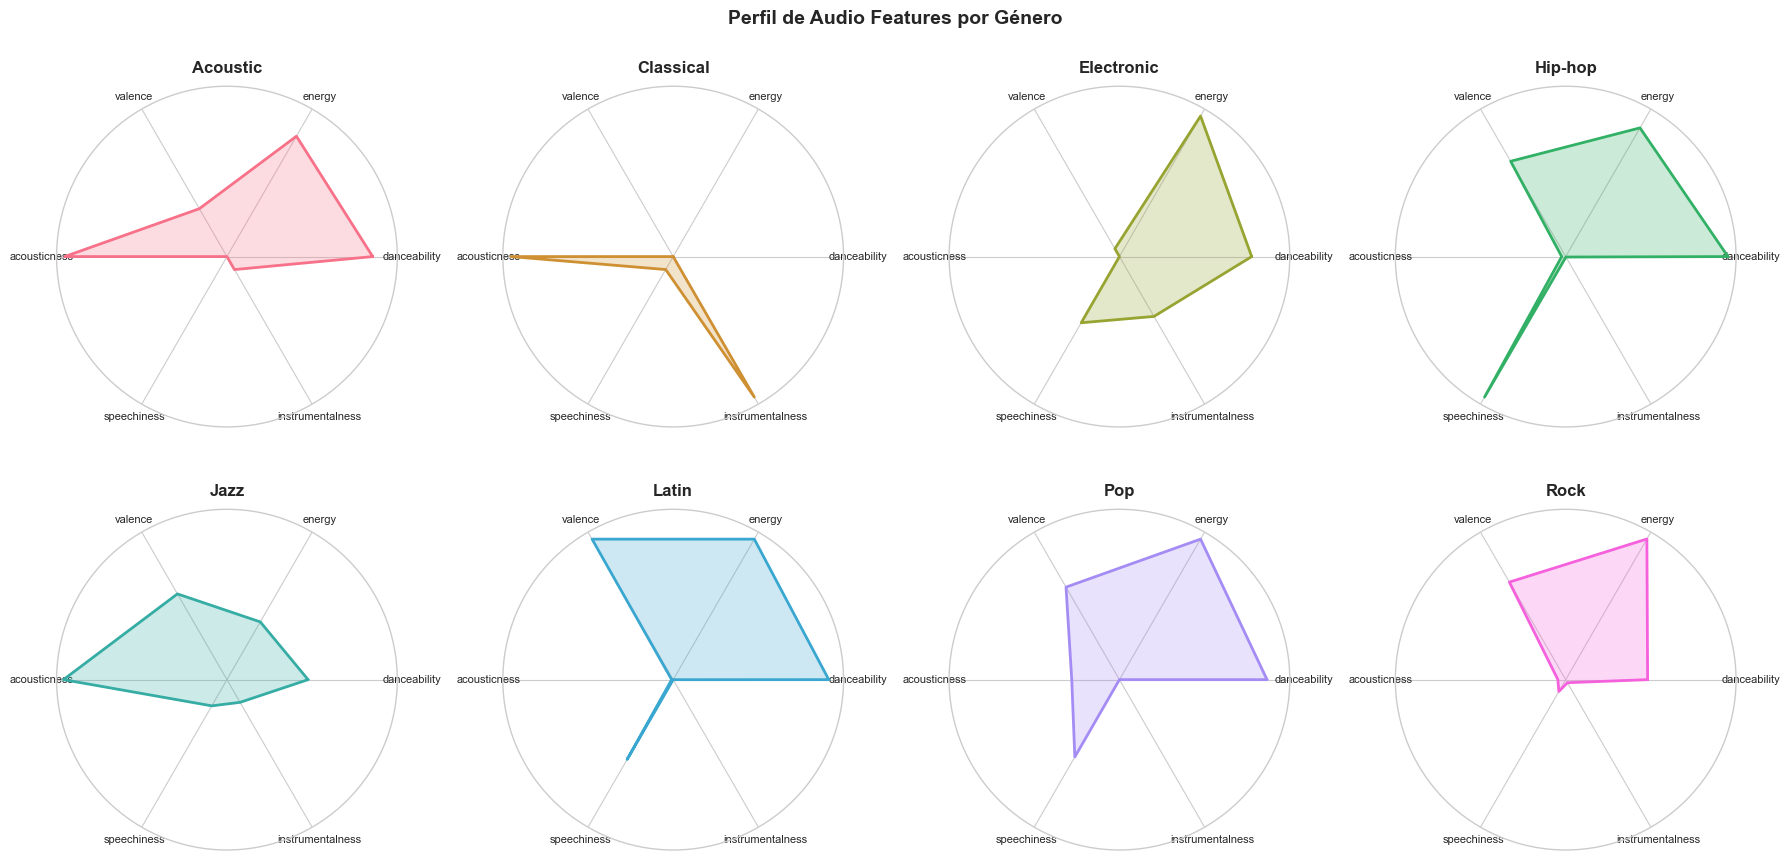

In [36]:
# Selección de géneros y features.
gen_selec = ['pop', 'rock', 'jazz', 'electronic', 'classical', 'hip-hop', 'latin', 'acoustic']
features_radar = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'instrumentalness']

df_radar = df[df['track_genre'].isin(gen_selec)].groupby('track_genre')[features_radar].mean()

# Noramlizamos entre 0 y 1.
df_radar_norm = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min())

angles = np.linspace(0, 2 * np.pi, len(features_radar), endpoint=False).tolist()
angles += angles[:1]

# Configuración de gráfico.
fig, axes = plt.subplots(2, 4, figsize=(18, 9), subplot_kw=dict(polar=True))
fig.suptitle('Perfil de Audio Features por Género', fontsize=14, fontweight='bold')
colors = sns.color_palette('husl', len(gen_selec))

for ax, (genero, color) in zip(axes.flatten(), zip(df_radar_norm.index, colors)):
    values = df_radar_norm.loc[genero].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features_radar, size=8)
    ax.set_yticks([])
    ax.set_title(genero.capitalize(), fontweight='bold', pad=10)

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('../reports/figures/radar_generos.png', dpi=150, bbox_inches='tight')
plt.show()

Son valores propios que parecen tener sentido, por ejemplo, el género acústico destaca en 'acousticness'.

#### Relación entre Energy vs Valence

In [37]:
# Medias por género.
df_scatter = df.groupby('track_genre')[['energy', 'valence', 'danceability']].mean().reset_index()

# Configuración de gráfico.
fig = px.scatter(df_scatter,x='energy',y='valence',size='danceability',color='track_genre',hover_name='track_genre',
                 title='Mapa de géneros: Energy vs Valence (tamaño = Danceability)',labels={'energy': 'Energy', 'valence': 'Valence'},width=950, height=600)

# Mostrar gráfico.
fig.update_layout(showlegend=False)
fig.write_html('../reports/figures/scatter_energy_valence.html')
fig.show()

Parece que la mayoría de géneros de spotify tiene valencia positiva y con energía media-alta.

#### Análisis de Contenido Explícito

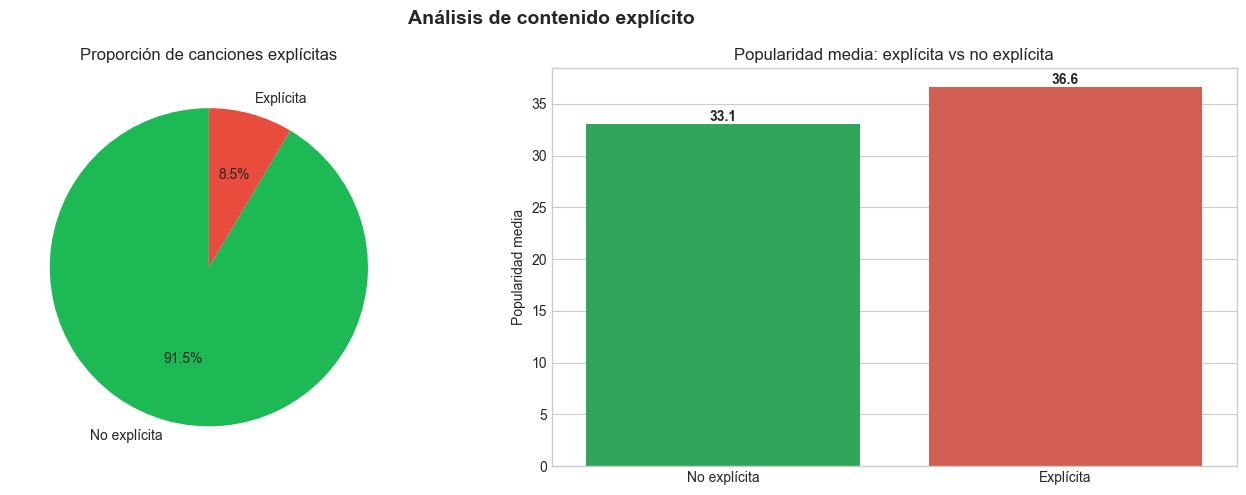

In [38]:
# Configuración de gráfico.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de contenido explícito', fontsize=14, fontweight='bold')

# Proporción explícitas vs no explícitas
explicit_counts = df['explicit'].value_counts()
labels = ['No explícita', 'Explícita']
axes[0].pie(explicit_counts.values, labels=labels, autopct='%1.1f%%', colors=['#1DB954', '#E74C3C'], startangle=90)
axes[0].set_title('Proporción de canciones explícitas')

# Popularidad media según explicit
pop_explicit = df.groupby('explicit')['popularity'].mean()
sns.barplot(x=['No explícita', 'Explícita'], y=pop_explicit.values,
            palette=['#1DB954', '#E74C3C'], ax=axes[1])
axes[1].set_title('Popularidad media: explícita vs no explícita')
axes[1].set_ylabel('Popularidad media')
for i, v in enumerate(pop_explicit.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')
    
# Mostrar gráficos.
plt.tight_layout()
plt.savefig('../reports/figures/explicitas.png', dpi=150, bbox_inches='tight')
plt.show()

La gran mayoría del catálogo de Spotify es para todos los públicos. Pero a la derecha se puede observar que la popularidad media es prácticamente la misma en los dos géneros.

#### Duración Media por Género

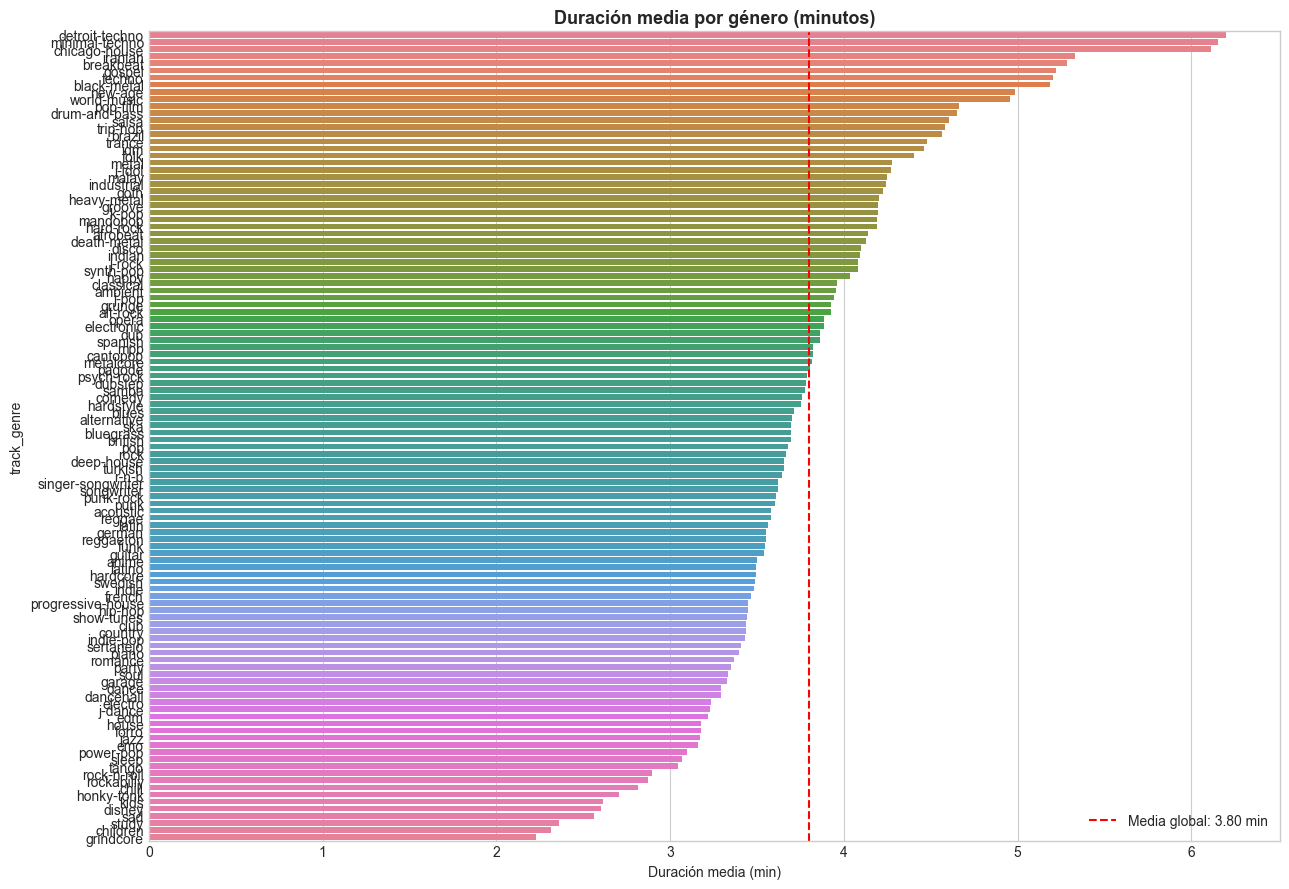

In [39]:
# Agrupación de la duración.
duracion_genero = df.groupby('track_genre')['duration_min'].mean().sort_values(ascending=False)

# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(13, 9))
sns.barplot(x=duracion_genero.values, y=duracion_genero.index, palette='husl', ax=ax)
ax.set_title('Duración media por género (minutos)', fontsize=13, fontweight='bold')
ax.set_xlabel('Duración media (min)')
ax.axvline(df['duration_min'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media global: {df["duration_min"].mean():.2f} min')
ax.legend()

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('../reports/figures/duracion_por_genero.png', dpi=150, bbox_inches='tight')
plt.show()

La media global es de 3.80 minutos, lo que equivale a 3 minutos y 48 segundos (total de 228 segundos). Las canciones electrónicas son las que tienen las duraciones más altas. Los géneros con duraciones más cortas son disney, infantiles y estudio.

#### Audio Features por Categoría de Popularidad

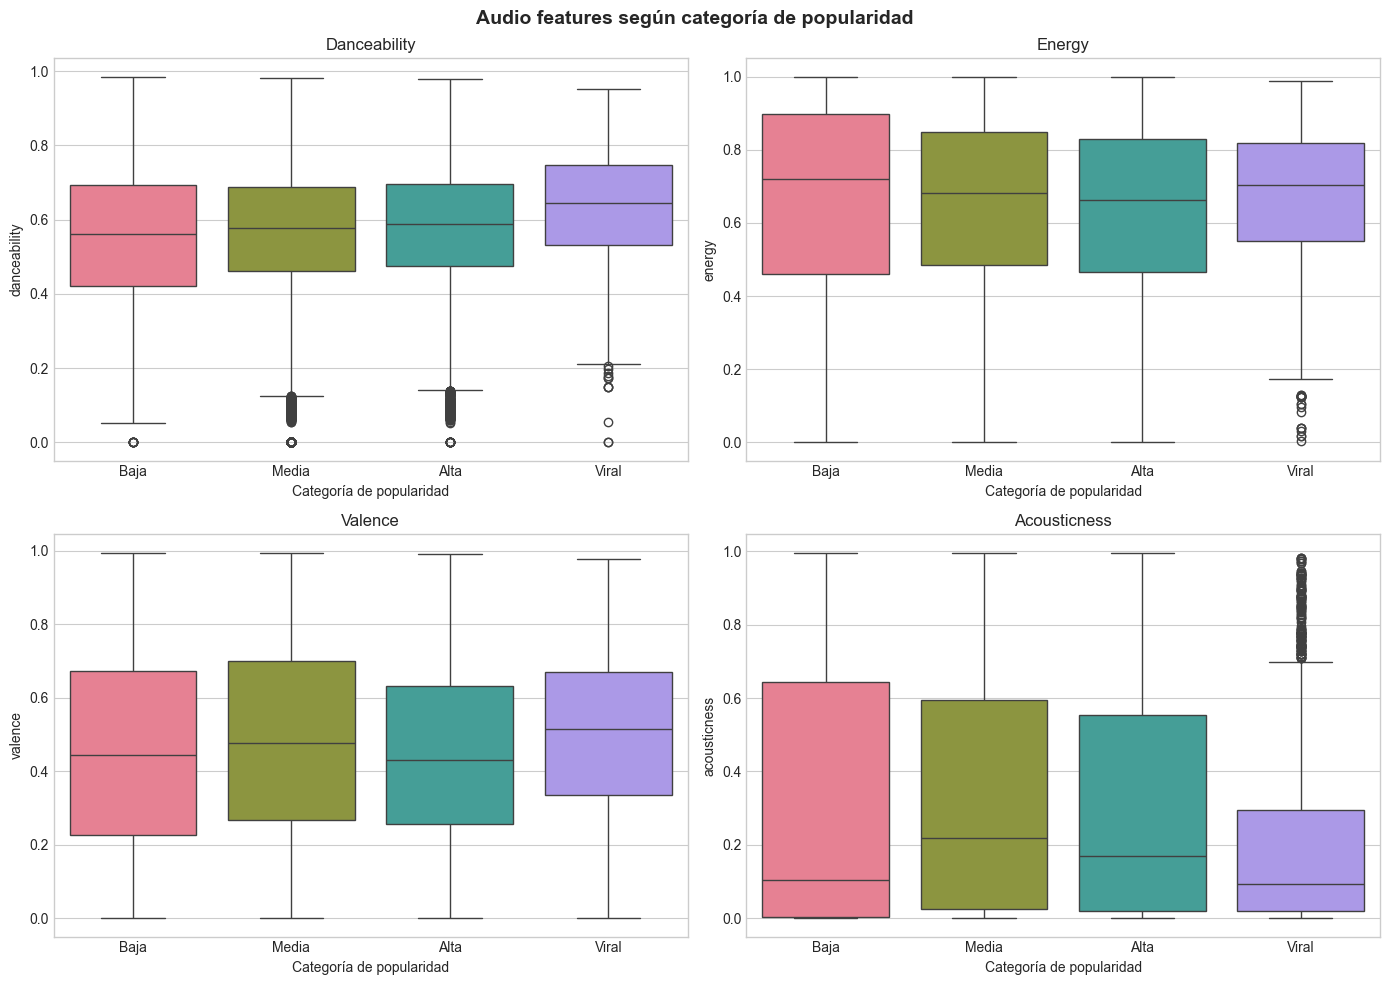

In [40]:
# Selección de variables para boxplot.
features_box = ['danceability', 'energy', 'valence', 'acousticness']
orden = ['Baja', 'Media', 'Alta', 'Viral']

# Configuración de gráfico.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Audio features según categoría de popularidad', fontsize=14, fontweight='bold')

for ax, feature in zip(axes.flatten(), features_box):
    sns.boxplot(data=df, x='popularity_category', y=feature,
                order=orden, palette='husl', ax=ax)
    ax.set_title(feature.capitalize())
    ax.set_xlabel('Categoría de popularidad')
    ax.set_ylabel(feature)

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('../reports/figures/boxplot_popularidad.png', dpi=150, bbox_inches='tight')
plt.show()

Las distribuciones son bastante similares entre todas las variables y la popularidad. Se pueden observar muchos outliers en la categoría viral y la feature 'acousticness'.